In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

columns = [
    "id", "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_largest_3_mean", "texture_largest_3_mean", "perimeter_largest_3_mean", "area_largest_3_mean", "smoothness_largest_3_mean",
    "compactness_largest_3_mean", "concavity_largest_3_mean", "concave_points_largest_3_mean", "symmetry_largest_3_mean", "fractal_dimension_largest_3_mean"
]

df = pd.read_csv("../data_raw/breast_cancer/wdbc.csv", header=None, names=columns)

 # drop id column as it is not useful for analysis
df.drop("id", axis=1, inplace=True)

# convert diagnosis to binary (1 for malignant, 0 for benign)
df["diagnosis"] = df.diagnosis.map({"M": 1, "B": 0}) 

In [2]:
df[df.eq(0).any(axis=1)]

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_largest_3_mean,texture_largest_3_mean,perimeter_largest_3_mean,area_largest_3_mean,smoothness_largest_3_mean,compactness_largest_3_mean,concavity_largest_3_mean,concave_points_largest_3_mean,symmetry_largest_3_mean,fractal_dimension_largest_3_mean
19,0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,15.110,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259
20,0,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,14.500,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183
21,0,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,10.230,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773
37,0,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,13.300,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169
46,0,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,8.964,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558,0,14.590,22.68,96.39,657.1,0.08473,0.13300,0.10290,0.037360,0.1454,...,15.480,27.27,105.90,733.5,0.10260,0.31710,0.36620,0.11050,0.2258,0.08004
559,0,11.510,23.93,74.52,403.5,0.09261,0.10210,0.11120,0.041050,0.1388,...,12.480,37.16,82.28,474.2,0.12980,0.25170,0.36300,0.09653,0.2112,0.08732
560,0,14.050,27.15,91.38,600.4,0.09929,0.11260,0.04462,0.043040,0.1537,...,15.300,33.17,100.20,706.7,0.12410,0.22640,0.13260,0.10480,0.2250,0.08321
561,0,11.200,29.37,70.67,386.0,0.07449,0.03558,0.00000,0.000000,0.1060,...,11.920,38.30,75.19,439.6,0.09267,0.05494,0.00000,0.00000,0.1566,0.05905


In [3]:
df["diagnosis"].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

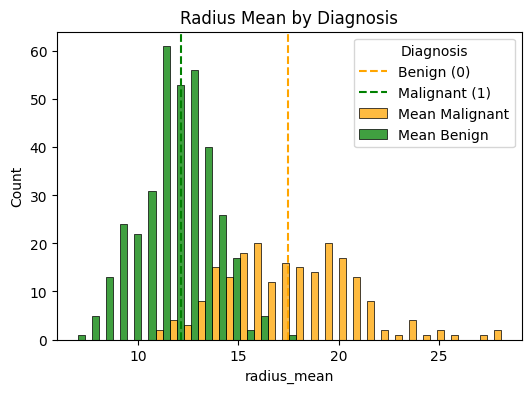

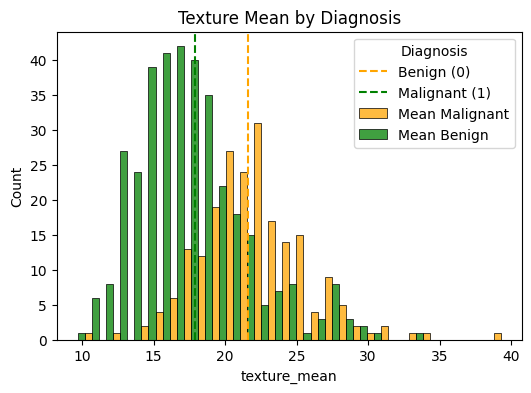

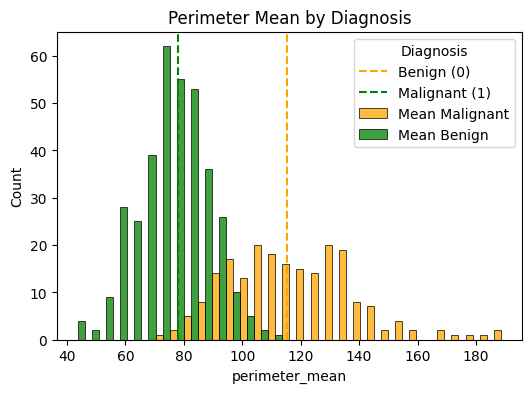

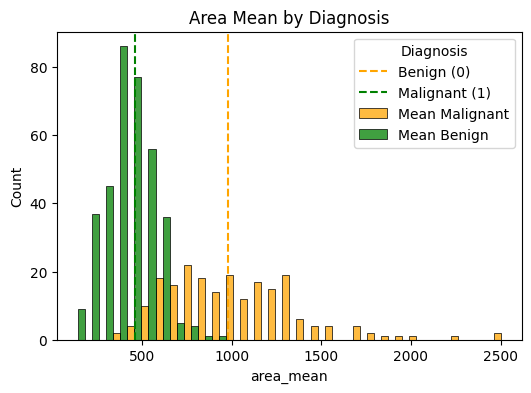

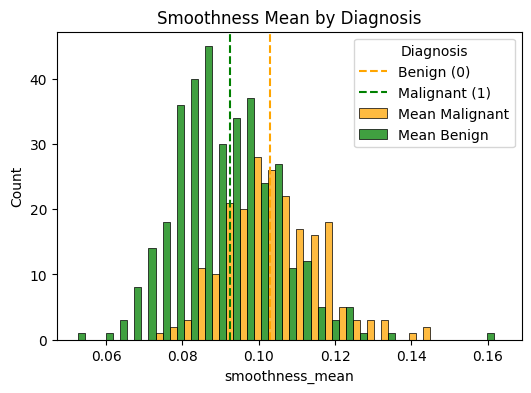

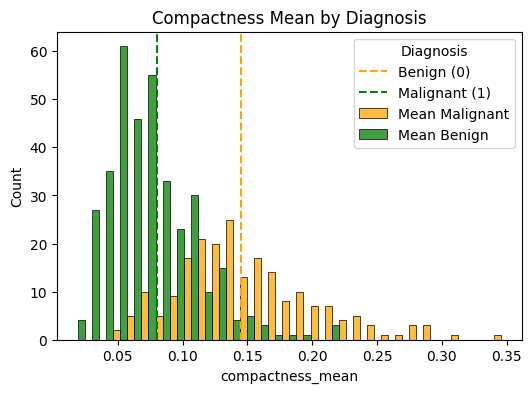

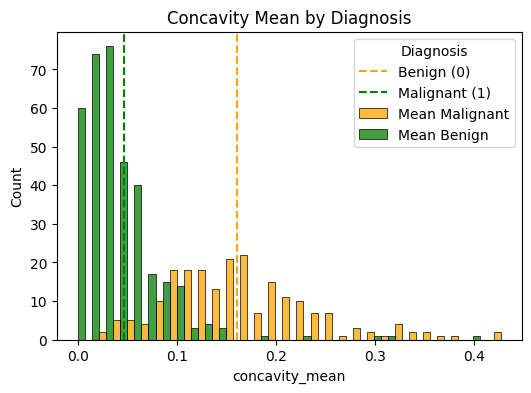

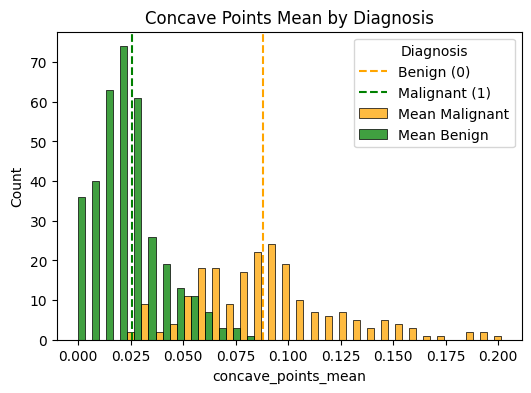

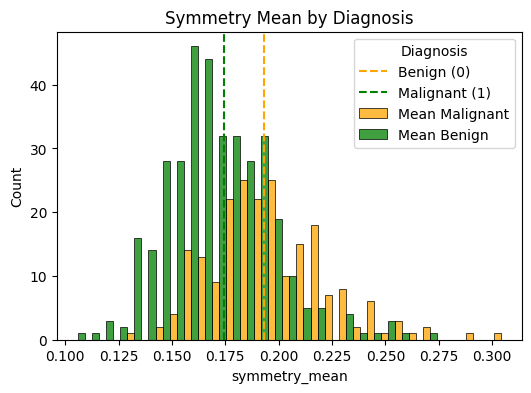

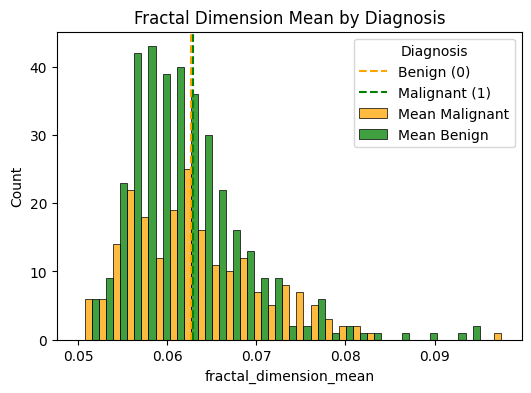

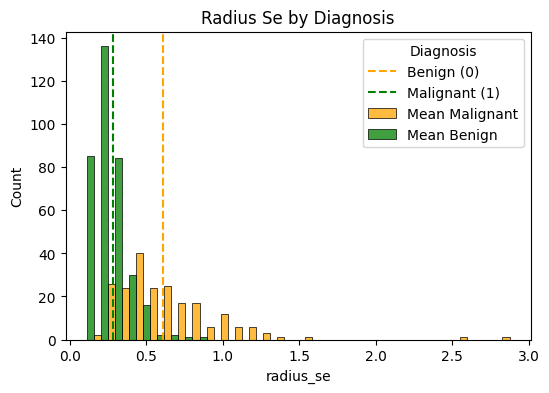

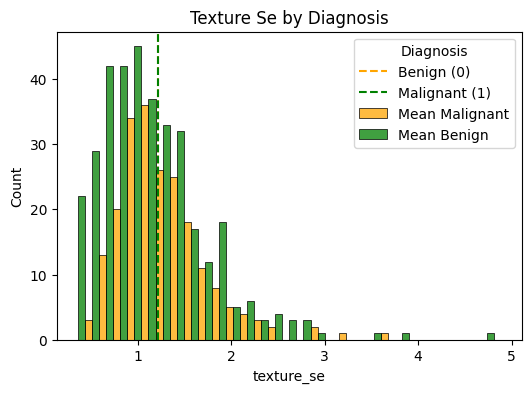

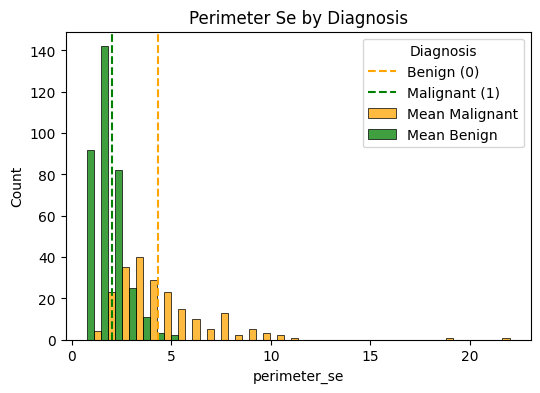

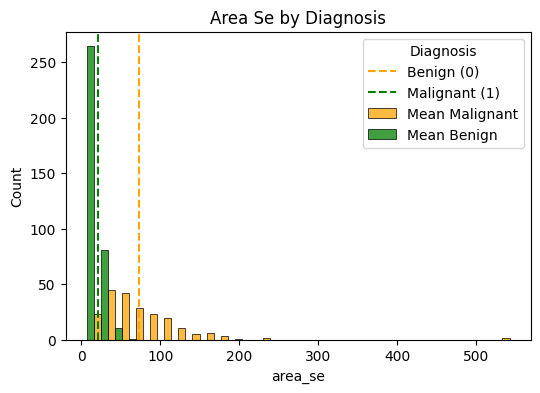

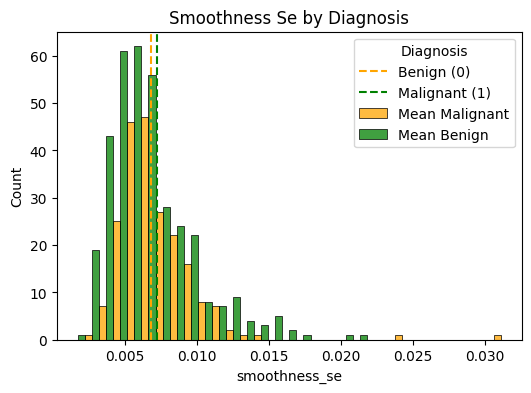

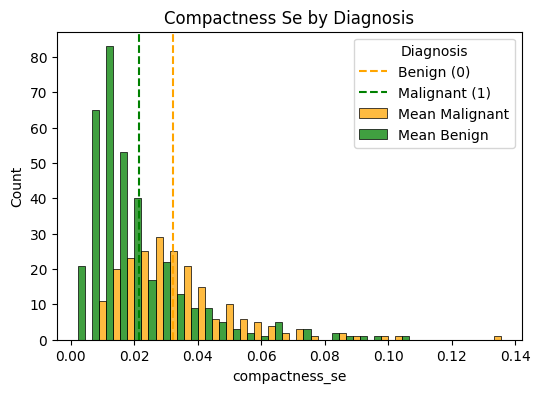

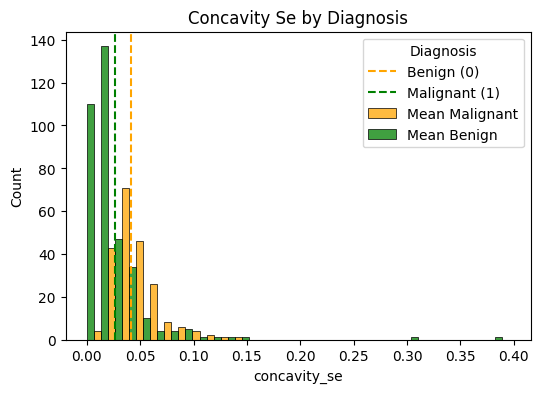

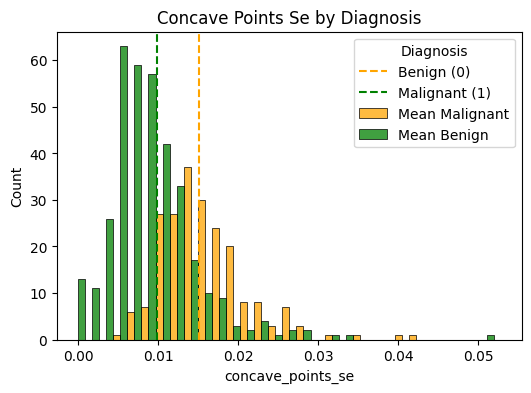

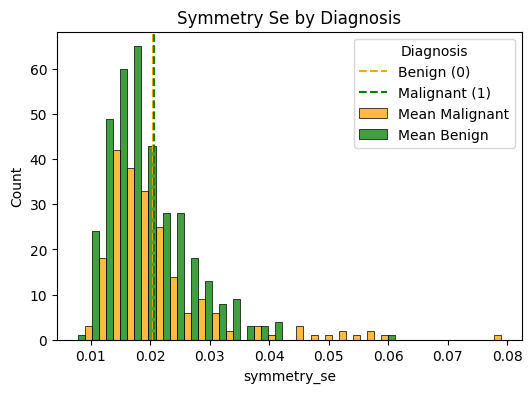

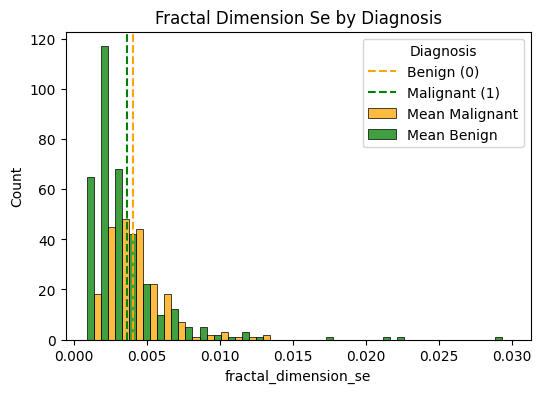

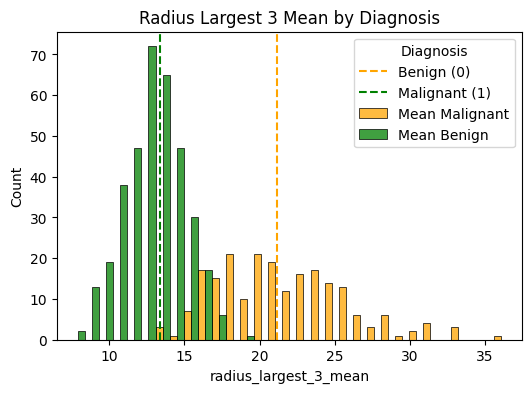

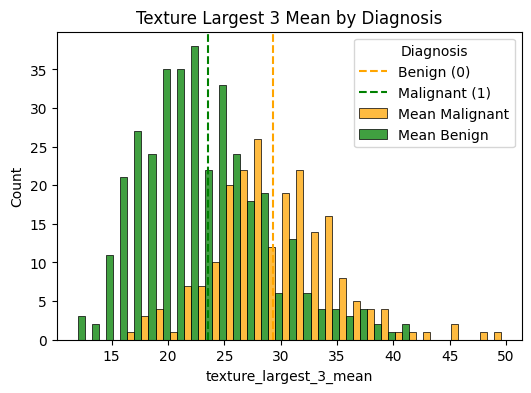

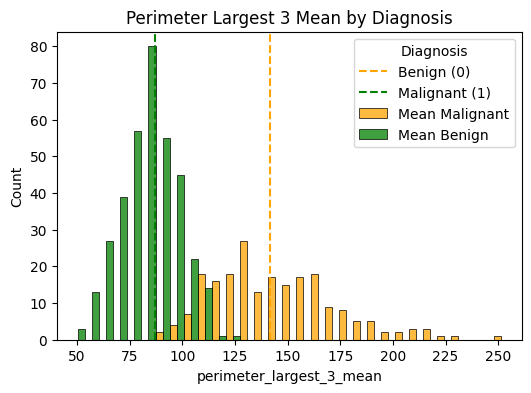

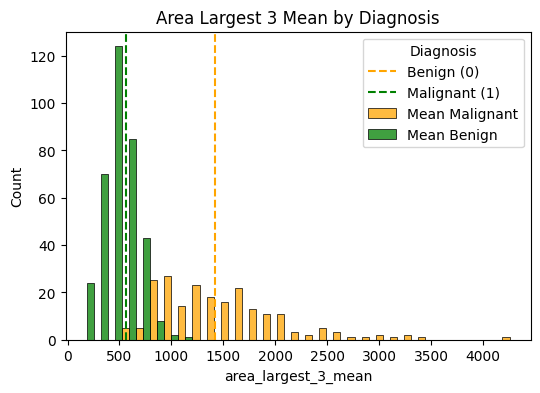

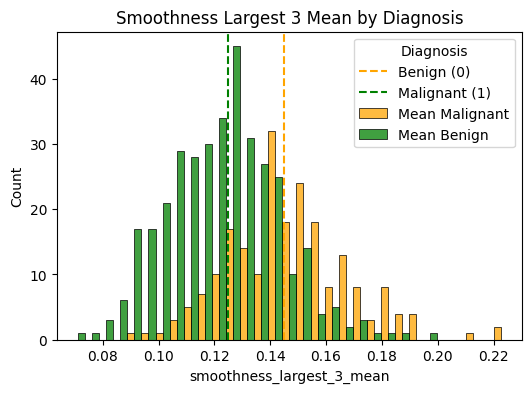

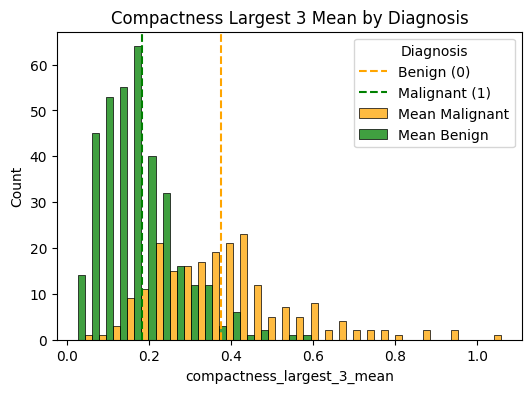

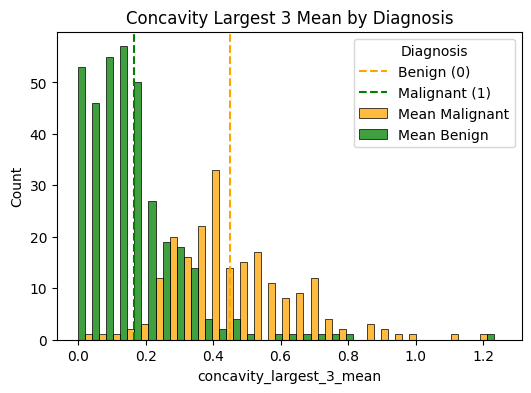

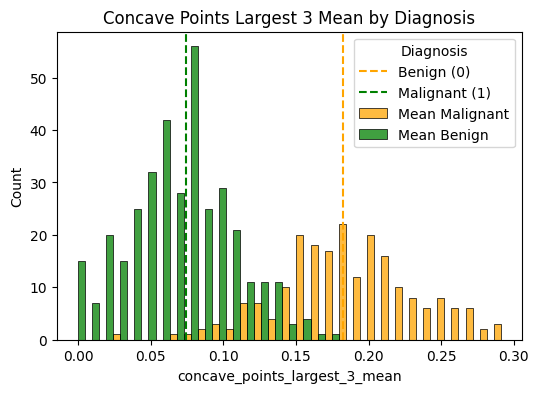

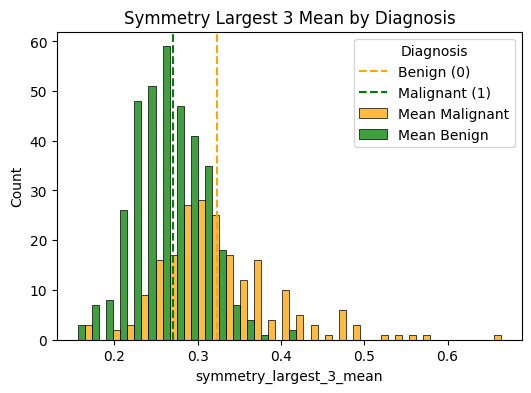

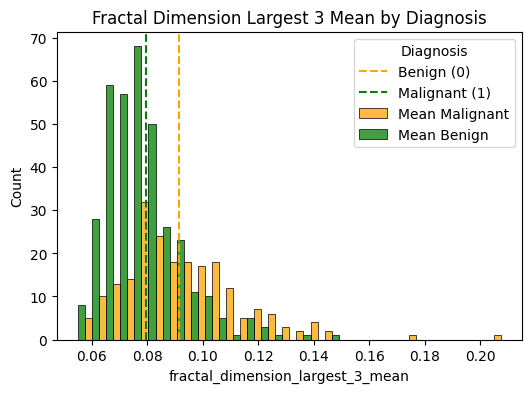

In [4]:
numeric_cols = [x for x in columns if x != "id" and x != "diagnosis"]

def format_col_name(col: str) -> str:
    col = col.replace("_", " ").title()
    return col

for col in numeric_cols:
    plt.figure(figsize=(6,4))

    sns.histplot(
        data=df,
        x=col,
        hue="diagnosis",
        multiple="dodge",
        bins=30,
        palette={0: "green", 1: "orange"} 
    )

    mean_1 = df[df["diagnosis"] == 1][col].mean()
    mean_0 = df[df["diagnosis"] == 0][col].mean()

    plt.axvline(mean_1, color="orange", linestyle="--")
    plt.axvline(mean_0, color="green", linestyle="--")

    plt.legend(
        title="Diagnosis",
        labels=["Benign (0)", "Malignant (1)", "Mean Malignant", "Mean Benign"]
    )

    plt.title(f"{format_col_name(col)} by Diagnosis")
    plt.show()

In [6]:
df.to_csv("../data_cleaned/breast_cancer.csv", index=False)